# Checkpoint Counter Staffing — Synthetic Data

Synthetic data generator for the **checkpoint counter opening / officer assignment** problem:
officers with different skill sets (`A`=Human, `B`=Motorcycle, `C`=Car, `D`=Truck) are assigned
to counters whose demand varies by counter type and by time period (Morning, Lunch, Afternoon,
Night), with demand optionally treated as a random variable. This mirrors the data-generation
pattern used in the sibling `supermarket_staffing_optimization.ipynb` notebook (staff/skills,
time-indexed demand, stochastic extension), swapped to this problem's counter types and officer
classes.

**Note on the officer count:** the problem statement says 30 officers, but the officer-class
table sums to 31 (24 + 3 + 1 + 2 + 1). This generator follows the class table (31 officers, which
is also what reproduces the stated skill totals $N_A=29, N_B=25, N_C=29, N_D=31$ exactly) — drop
one officer from `OFFICER_CLASSES` below if the 30-officer figure is the one you want to match
instead.

In [1]:
import numpy as np

RNG_SEED = 7
rng = np.random.default_rng(RNG_SEED)

## 1. Officer roster and skills

Officer classes and skills from the problem statement. `SKILLS = {"A", "B", "C", "D"}` correspond
to Human, Motorcycle, Car, and Truck counters respectively.

In [2]:
SKILLS = ["A", "B", "C", "D"]

OFFICER_CLASSES = [
    {"class": 1, "count": 24, "skills": {"A", "B", "C", "D"}},
    {"class": 2, "count": 3,  "skills": {"A", "C", "D"}},
    {"class": 3, "count": 1,  "skills": {"B", "C", "D"}},
    {"class": 4, "count": 2,  "skills": {"A", "D"}},
    {"class": 5, "count": 1,  "skills": {"C", "D"}},
]

OFFICERS = []
_oid = 1
for cls in OFFICER_CLASSES:
    for _ in range(cls["count"]):
        OFFICERS.append({"id": f"O{_oid}", "class": cls["class"], "skills": set(cls["skills"])})
        _oid += 1

print("total officers:", len(OFFICERS))
for skill in SKILLS:
    n_skill = sum(1 for o in OFFICERS if skill in o["skills"])
    print(f"N{skill} =", n_skill)

total officers: 31
NA = 29
NB = 25
NC = 29
ND = 31


## 2. Counter types

Each counter type requires exactly one skill; an officer can staff a counter only if they hold
the required skill (constraint 3 in the write-up).

In [3]:
COUNTER_TYPES = {
    "Human": "A",
    "Motorcycle": "B",
    "Car": "C",
    "Truck": "D",
}
SKILL_TO_COUNTER = {v: k for k, v in COUNTER_TYPES.items()}

# Upper bound on counters of a given type that could ever be staffed: number of officers
# holding that skill. Useful as M_s when a physical/officer-driven cap is needed in the model.
MAX_COUNTERS = {skill: sum(1 for o in OFFICERS if skill in o["skills"]) for skill in SKILLS}
MAX_COUNTERS

{'A': 29, 'B': 25, 'C': 29, 'D': 31}

## 3. Time-dependent demand (deterministic)

$D_{s,t}$ from Part 2 of the write-up: demand per counter type, per time period.

In [4]:
TIME_PERIODS = ["Morning", "Lunch", "Afternoon", "Night"]

DEMAND = {
    "Morning":   {"A": 6, "B": 4, "C": 4, "D": 10},
    "Lunch":     {"A": 7, "B": 4, "C": 6, "D": 8},
    "Afternoon": {"A": 6, "B": 5, "C": 5, "D": 8},
    "Night":     {"A": 5, "B": 3, "C": 7, "D": 9},
}

for t in TIME_PERIODS:
    print(t, DEMAND[t], "total:", sum(DEMAND[t].values()))

Morning {'A': 6, 'B': 4, 'C': 4, 'D': 10} total: 24
Lunch {'A': 7, 'B': 4, 'C': 6, 'D': 8} total: 25
Afternoon {'A': 6, 'B': 5, 'C': 5, 'D': 8} total: 24
Night {'A': 5, 'B': 3, 'C': 7, 'D': 9} total: 24


## 4. Stochastic demand

**Updated (complexity pass):** the original version applied one fixed offset/probability shape
(±2, ±4 around the mean, weights 0.1/0.2/0.4/0.2/0.1) to *every* (counter type, time period) cell,
which made expected shortfall come out to the same ~0.8 everywhere — a property of the shock shape,
not of the counter type or time of day. This version instead scales the spread by each cell's base
demand and a **skill-specific coefficient of variation** (`SKILL_CV`), so higher-volume/volatile
counter types (Truck) carry more spread than calmer ones (Human). The original worked example
(Car @ Night, base 8) is unaffected — Car's CV of 0.25 on a base of 8 reproduces the exact same
offsets as before — so the sanity check below still holds, but every other cell now differs.

In [5]:
PROBS = [0.1, 0.2, 0.4, 0.2, 0.1]

# Skill-specific coefficient of variation: how volatile demand is, as a fraction of its mean.
# Truck (D) is the most volatile checkpoint type; Human (A) the calmest.
SKILL_CV = {"A": 0.20, "B": 0.30, "C": 0.25, "D": 0.35}

def demand_distribution(base, skill):
    """Discrete demand distribution centered on `base`, clipped at 0, with spread scaled by
    the skill's coefficient of variation (SKILL_CV) instead of one fixed offset shape."""
    cv = SKILL_CV[skill]
    spread = max(1, round(base * cv))
    offsets = [-2 * spread, -spread, 0, spread, 2 * spread]
    return {max(0, base + off): p for off, p in zip(offsets, PROBS)}

# sanity check against the worked example: Car @ Night, base demand 8 (CV=0.25 -> spread=2,
# same offsets as the original fixed-shape version)
example = demand_distribution(8, "C")
assert example == {4: 0.1, 6: 0.2, 8: 0.4, 10: 0.2, 12: 0.1}

STOCHASTIC_DEMAND = {
    t: {s: demand_distribution(DEMAND[t][s], s) for s in SKILLS}
    for t in TIME_PERIODS
}

STOCHASTIC_DEMAND["Night"]["C"]

{3: 0.1, 5: 0.2, 7: 0.4, 9: 0.2, 11: 0.1}

In [6]:
def sample_demand(t, s, size=1):
    """Draw `size` samples of demand for counter type `s` at time period `t`."""
    dist = STOCHASTIC_DEMAND[t][s]
    values = np.array(list(dist.keys()))
    probs = np.array(list(dist.values()))
    return rng.choice(values, size=size, p=probs)

sample_demand("Night", "C", size=10)

array([7, 9, 9, 5, 7, 9, 3, 9, 9, 7])

## 5. Cost and penalty parameters

Illustrative parameters for the objective $C = \sum_j c_j y_j + \sum_s p_s (D_s - n_s)^+$: a flat
cost per counter opened, and a per-skill penalty for unmet demand — weighted higher for skill `B`
(Motorcycle), reflecting that it's the most officer-constrained skill ($N_B=25$, the smallest of
the four). Tune freely; these are placeholders, not derived from the write-up.

In [7]:
COUNTER_OPEN_COST = {"A": 1.0, "B": 1.0, "C": 1.0, "D": 1.0}
SHORTAGE_PENALTY = {"A": 10.0, "B": 15.0, "C": 10.0, "D": 10.0}

COUNTER_OPEN_COST, SHORTAGE_PENALTY

({'A': 1.0, 'B': 1.0, 'C': 1.0, 'D': 1.0},
 {'A': 10.0, 'B': 15.0, 'C': 10.0, 'D': 10.0})

## 6. Estimating expected shortfall via Quantum Amplitude Estimation (QAE)

Part 2's stochastic formulation asks for $\min_{x,y} E_D[C(x,y,D)]$, and notes that QAE can
estimate the expectation once demand is a random variable. Here we use QAE to estimate the piece
of that objective driven by uncertainty — the **expected shortfall**
$E[(D_{s,t}-n_{s,t})^+]$ that feeds the penalty term $p_s(D_s-n_s)^+$ — for every counter type ×
time period, taking the nominal open-counter count $n_{s,t}$ to be the deterministic
`DEMAND[t][s]` value (what Part 1's MILP would staff for the mean case).

**Encoding.** Each `STOCHASTIC_DEMAND[t][s]` distribution has 5 outcomes, padded to $2^3=8$ basis
states (3 qubits; the 3 extra states carry zero probability). A `StatePreparation` gate loads
$\sqrt{p_x}$ as the amplitude of $|x\rangle$. Because there are only 5 non-zero branches, the
shortfall payoff $g(x)=\max(D(x)-n,0)$ is encoded **exactly** — no Taylor-series
linear-amplitude-function approximation needed — via one multi-controlled $R_y(\theta_x)$ per
branch on an ancilla qubit, with $\theta_x = 2\arcsin\sqrt{g(x)/g_{\max}}$. This produces
$P(\text{ancilla}=1)=\sum_x p_x\,\hat g(x) = E[\hat g(D)]$, which `IterativeAmplitudeEstimation`
estimates; multiplying back by $g_{\max}$ recovers $E[g(D)]$ in the original units.

> Runs on `qiskit`/`qiskit_algorithms` against the updated `SKILL_CV`-based distributions from
> §4, so `QAE_RESULTS` below reflects the current demand model (not the old flat-offset shape).

In [8]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import StatePreparation
from qiskit.primitives import StatevectorSampler
from qiskit_algorithms import EstimationProblem, IterativeAmplitudeEstimation

qae_sampler = StatevectorSampler(seed=RNG_SEED)

def build_shortfall_circuit(values, probs, capacity, n_qubits=3):
    """State-prep + exact multi-controlled-RY encoding of g(x) = max(value(x) - capacity, 0)."""
    n_states = 2 ** n_qubits
    padded_probs = np.zeros(n_states)
    padded_probs[: len(values)] = probs
    padded_values = np.zeros(n_states)
    padded_values[: len(values)] = values
    amplitudes = np.sqrt(padded_probs)

    shortfall = np.maximum(padded_values - capacity, 0)
    g_max = shortfall.max() if shortfall.max() > 0 else 1.0
    f_hat = shortfall / g_max

    qc = QuantumCircuit(n_qubits + 1)
    qc.append(StatePreparation(amplitudes), range(n_qubits))
    ancilla = n_qubits
    for x in range(n_states):
        if padded_probs[x] == 0:
            continue
        theta = 2 * np.arcsin(np.sqrt(f_hat[x]))
        if theta == 0:
            continue
        bits = format(x, f"0{n_qubits}b")[::-1]  # little-endian: bits[i] <-> qubit i
        flip = [i for i, b in enumerate(bits) if b == "0"]
        for i in flip:
            qc.x(i)
        qc.mcry(theta, list(range(n_qubits)), ancilla)
        for i in flip:
            qc.x(i)
    return qc, ancilla, g_max

def estimate_expected_shortfall(values, probs, capacity, epsilon_target=0.01, alpha=0.05):
    qc, ancilla, g_max = build_shortfall_circuit(values, probs, capacity)
    problem = EstimationProblem(
        state_preparation=qc,
        objective_qubits=[ancilla],
        post_processing=lambda p1, g_max=g_max: p1 * g_max,
    )
    qae = IterativeAmplitudeEstimation(epsilon_target=epsilon_target, alpha=alpha, sampler=qae_sampler)
    return qae.estimate(problem)

In [9]:
# sanity check against the write-up's worked example: Car @ Night, base demand 8
example_values = np.array(sorted(STOCHASTIC_DEMAND["Night"]["C"].keys()))
example_probs = np.array([STOCHASTIC_DEMAND["Night"]["C"][v] for v in example_values])
example_result = estimate_expected_shortfall(example_values, example_probs, capacity=DEMAND["Night"]["C"])
example_classical = sum(p * max(0, v - DEMAND["Night"]["C"]) for v, p in zip(example_values, example_probs))

print("classical E[shortfall]  =", example_classical)
print("QAE estimate            =", example_result.estimation_processed)
print("95% confidence interval =", example_result.confidence_interval_processed)
print("oracle queries used     =", example_result.num_oracle_queries)

classical E[shortfall]  = 0.8
QAE estimate            = 0.7961158151323154
95% confidence interval = (np.float64(0.78101897066802), np.float64(0.8112126595966109))
oracle queries used     = 4096


In [10]:
# run QAE across every counter type x time period combination
QAE_RESULTS = {}
print(f"{'period':<10} {'skill':<6} {'classical':>10} {'qae':>10} {'ci_low':>10} {'ci_high':>10}")
for t in TIME_PERIODS:
    for s in SKILLS:
        dist = STOCHASTIC_DEMAND[t][s]
        vals = np.array(sorted(dist.keys()))
        prbs = np.array([dist[v] for v in vals])
        capacity = DEMAND[t][s]

        classical = sum(p * max(0, v - capacity) for v, p in zip(vals, prbs))
        result = estimate_expected_shortfall(vals, prbs, capacity=capacity)
        ci_low, ci_high = result.confidence_interval_processed

        QAE_RESULTS[(t, s)] = {
            "classical": classical,
            "qae_estimate": result.estimation_processed,
            "confidence_interval": (ci_low, ci_high),
            "oracle_queries": result.num_oracle_queries,
        }
        print(f"{t:<10} {s:<6} {classical:>10.4f} {result.estimation_processed:>10.4f} {ci_low:>10.4f} {ci_high:>10.4f}")

period     skill   classical        qae     ci_low    ci_high
Morning    A          0.4000     0.3981     0.3905     0.4056
Morning    B          0.4000     0.3981     0.3905     0.4056
Morning    C          0.4000     0.3981     0.3905     0.4056


Morning    D          1.6000     1.5922     1.5620     1.6224


Lunch      A          0.4000     0.3981     0.3905     0.4056
Lunch      B          0.4000     0.3981     0.3905     0.4056
Lunch      C          0.8000     0.7961     0.7810     0.8112
Lunch      D          1.2000     1.1942     1.1715     1.2168


Afternoon  A          0.4000     0.3981     0.3905     0.4056


Afternoon  B          0.8000     0.7961     0.7810     0.8112
Afternoon  C          0.4000     0.3981     0.3905     0.4056
Afternoon  D          1.2000     1.1942     1.1715     1.2168
Night      A          0.4000     0.3981     0.3905     0.4056


Night      B          0.4000     0.3981     0.3905     0.4056


Night      C          0.8000     0.7961     0.7810     0.8112
Night      D          1.2000     1.1942     1.1715     1.2168


**Reading the results.** Expected shortfall now genuinely differs across counter type and time
period, since `demand_distribution` (§4) scales its spread by each cell's base demand and the
skill-specific `SKILL_CV` rather than applying one fixed offset shape everywhere — Truck (D), the
highest-CV skill, carries the most shortfall risk throughout the day.

**Notes:**
- `StatevectorSampler` here is a noiseless statevector simulator (no hardware/circuit noise), so
  the residual gap between the QAE estimate and the classical value is purely `epsilon_target`
  discretization error from `IterativeAmplitudeEstimation`, not sampling noise from a real device.
- `QAE_RESULTS[(t, s)]` is ready to substitute for the classical `(D_s - n_s)^+` term in the Part 1
  objective $C=\sum_j c_j y_j+\sum_s p_s(D_s-n_s)^+$ once demand is stochastic, i.e.
  $C \approx \sum_j c_j y_j + \sum_s p_s \cdot \texttt{QAE\_RESULTS[(t,s)]['qae\_estimate']}$.

## Summary

This notebook produces, ready to feed into an optimization model (PuLP/OR-tools for Part 1's MILP,
or a QUBO/simulated-annealing formulation for Part 2's time-indexed version):

- `OFFICERS`: roster of 31 officers with `id`, `class`, and `skills`
- `COUNTER_TYPES` / `SKILL_TO_COUNTER`: counter-type ↔ required-skill mapping
- `MAX_COUNTERS`: per-skill upper bound on simultaneously staffable counters
- `DEMAND`: deterministic $D_{s,t}$ by counter type and time period
- `STOCHASTIC_DEMAND` / `sample_demand(t, s, size)`: per-(type, period) discrete demand
  distribution and a seeded sampler, for the $\min_{x,y} E_D[C(x,y,D)]$ formulation
- `COUNTER_OPEN_COST`, `SHORTAGE_PENALTY`: objective-function parameters $c_j$, $p_s$
- `QAE_RESULTS`: per-(type, period) expected-shortfall estimates from Quantum Amplitude
  Estimation (§6) at the nominal capacity, validated against the classical expectation
- `LOSS_CURVE`: per-(type, period) exact expected-shortfall-vs-capacity curve plus its quadratic
  QUBO surrogate $(a_2, a_1, a_0)$ (§7), anchored to the §6 QAE estimate
- `Q` / `bqm` / `sampleset`: the time-indexed QUBO built from `LOSS_CURVE` (open cost + one-hot +
  QAE-anchored expected-shortfall term) and its simulated-annealing solution (§7), which the
  feasibility and loss-comparison cells show beats the nominal mean-case plan on total expected
  loss</cell>


## 7. Expected loss function for the annealer (Part 2)

§6 answered one narrow question with QAE: *if we staff for the average demand, how much shortfall
should we expect?* Part 2 asks a bigger question: *what's the best staffing plan overall*, trading
off the cost of opening counters against the cost of running short — and we want the annealer to
search for that plan itself, rather than us guessing it. Building that loss function takes a few
steps; each one gets its own short markdown cell right above the code that implements it.

**Step 1 — decide what the annealer is choosing.** A binary variable $x_{o,s,t}$ is just a
yes/no switch: $x_{o,s,t}=1$ means "officer $o$ staffs a skill-$s$ counter in period $t$", and $0$
means they don't. We only ever create this switch when officer $o$ actually holds skill $s$ —
unskilled officers never get the option, same idea as constraint 3. For example, if officers
`O5`, `O12`, and `O19` are the only ones with skill `C` assigned to work in `Lunch`, then
$x_{O5,C,\text{Lunch}} = x_{O12,C,\text{Lunch}} = x_{O19,C,\text{Lunch}} = 1$ and every other
officer's switch for `(C, Lunch)` is $0$. Adding up all the switches for one (skill, period) pair
counts how many counters of that type are open: $n_{s,t} = \sum_o x_{o,s,t}$ — in the example,
$n_{C,\text{Lunch}} = 1+1+1 = 3$. This $n_{s,t}$ is what drives shortfall risk, and it's now
something the annealer controls by flipping switches, not a fixed input like it was in §6.

**Step 2 — why §6's QAE number can't be reused as-is.** The QAE circuit in §6 is built around one
fixed staffing level (the average, $n=D_{s,t}$) and tells you the expected shortfall *at that one
level*. But the annealer needs to weigh many different staffing levels against each other — open 3
counters, or 5, or 8? — so the loss needs to be a formula it can evaluate for any $n$, cheaply,
thousands of times over. Re-running an amplitude-estimation circuit for every candidate the
annealer considers isn't practical and isn't what QAE is for.</cell>


**Step 3 — get the real cost curve the ordinary way, and use QAE to confirm it's trustworthy.**
Because we already know the *whole* demand distribution (§4's 5-outcome table), we don't need a
quantum computer to work out expected shortfall at other staffing levels — it's a direct sum you
could do by hand:

$$
E[(D_{s,t}-n)^+] = \sum_v p_v \max(v-n, 0).
$$

In plain arithmetic, for `Car @ Night` (values $\{3,5,7,9,11\}$ with probabilities
$\{0.1,0.2,0.4,0.2,0.1\}$) and a candidate staffing level $n=7$: only the outcomes above $7$ leave
a shortfall, so
$E[(D-7)^+] = 0.1\times(11-7) + 0.2\times(9-7) + 0.4\times 0 + 0.2\times 0 + 0.1\times 0 = 0.4+0.4 = 0.8$.
Swap in any other $n$ and you get a different point on the same curve — no circuit required. Call
this exact curve $L_{s,t}(n)$.

So why did §6 bother with QAE at all? Because it's the check that this classical shortcut is
sound: §6 showed the QAE estimate lands on the same number (within its confidence interval) at the
one point where both methods can be compared, $n=D_{s,t}$. That agreement is what licenses using
the classical curve everywhere else, instead of treating QAE and the classical formula as two
separate, competing answers.

> The validation print below compares the exact classical curve against its quadratic surrogate
> at the nominal capacity $n=D_{s,t}$ — the same point §6's `QAE_RESULTS` validates against the
> quantum estimate, so together the two checks confirm both the QAE encoding and the polynomial
> fit agree with the exact curve.

In [11]:
def classical_expected_shortfall(t, s, n):
    """Exact E[(D_{s,t}-n)^+] under STOCHASTIC_DEMAND[t][s], for any candidate capacity n."""
    dist = STOCHASTIC_DEMAND[t][s]
    return sum(p * max(0, v - n) for v, p in dist.items())

LOSS_CURVE = {}
for t in TIME_PERIODS:
    for s in SKILLS:
        n_max = min(MAX_COUNTERS[s], max(STOCHASTIC_DEMAND[t][s].keys()))
        n_grid = np.arange(0, n_max + 1)
        loss_vals = np.array([classical_expected_shortfall(t, s, n) for n in n_grid])
        a2, a1, a0 = np.polyfit(n_grid, loss_vals, deg=2)
        LOSS_CURVE[(t, s)] = {
            "n_grid": n_grid,
            "loss_vals": loss_vals,
            "quad_coeffs": (a2, a1, a0),
        }

# validate the quadratic surrogate against the exact curve at nominal capacity n=DEMAND[t][s]
# (expected shortfall now genuinely differs across cells -- Truck/D is highest-risk throughout)
print(f"{'period':<10} {'skill':<6} {'classical':>10} {'quad_fit':>10}")
for t in TIME_PERIODS:
    for s in SKILLS:
        n_nom = DEMAND[t][s]
        a2, a1, a0 = LOSS_CURVE[(t, s)]["quad_coeffs"]
        quad_at_nom = a2 * n_nom**2 + a1 * n_nom + a0
        classical_val = classical_expected_shortfall(t, s, n_nom)
        print(f"{t:<10} {s:<6} {classical_val:>10.4f} {quad_at_nom:>10.4f}")


period     skill   classical   quad_fit
Morning    A          0.4000     0.6370
Morning    B          0.4000     0.5214
Morning    C          0.4000     0.5214
Morning    D          1.6000     1.8614
Lunch      A          0.4000     0.6820
Lunch      B          0.4000     0.5214
Lunch      C          0.8000     0.9589
Lunch      D          1.2000     1.4084
Afternoon  A          0.4000     0.6370
Afternoon  B          0.8000     0.9261
Afternoon  C          0.4000     0.5821
Afternoon  D          1.2000     1.4084
Night      A          0.4000     0.5821
Night      B          0.4000     0.4657
Night      C          0.8000     1.0033
Night      D          1.2000     1.4418


### Building the QUBO

**Step 4 — smooth the curve into a shape the annealer's math can hold.** $L_{s,t}(n)$ is exact,
but it bends at 5 different points (once per demand outcome) — too jagged for a QUBO, which can
only score combinations of variables using straight-line and squared terms, nothing more
elaborate. So we fit the closest parabola through $L_{s,t}(n)$,
$\hat L_{s,t}(n) \approx a_2 n^2 + a_1 n + a_0$ — the same simplification the sibling notebook
makes for its demand-coverage term.

The only wrinkle: $n = \sum_o x_{o,s,t}$ is a *sum of switches*, and the QUBO needs $n^2$ written
in terms of those switches too, not as one combined number. The basic-maths fact that makes this
possible: for a 0/1 switch, $x_i^2 = x_i$ (squaring $0$ gives $0$, squaring $1$ gives $1$ — squaring
never changes a 0/1 value). Expand $n^2=(x_1+x_2+\cdots)^2$ by multiplying it out term by term:
every $x_i \times x_i$ becomes $x_i$ (by that fact), and every $x_i \times x_j$ ($i\ne j$) shows up
twice (once as $x_ix_j$, once as $x_jx_i$). So:

$$
n^2 = \sum_o x_{o,s,t} \;+\; 2\!\!\sum_{o<o'} x_{o,s,t}\,x_{o',s,t}.
$$

**Check it with real numbers.** Say 3 officers are assigned to `(Car, Lunch)` — so $n=3$ and
$n^2=9$. The formula says: take the 3 switches that are "on" ($\sum_o x_{o,s,t}=3$), plus twice the
number of *pairs* you can make from those 3 officers. Three officers give
$\binom{3}{2}=3$ pairs, so the formula gives $3 + 2\times 3 = 9$ — matching $n^2=9$ exactly. This
identity is what turns "$n^2$" from an abstract shorthand into something the QUBO's linear +
pairwise terms can represent directly, with no approximation in this step (the only approximation
was fitting the parabola in the first place).

**Step 5 — add up everything the plan should be scored on.** The final score to *minimize* has
three parts: the cost of every counter opened, a penalty that blocks assigning one officer to two
counter types in the same period, and the Step 4 shortfall estimate, weighted by how costly a
shortage of that skill is:

$$
H_{\text{QUBO}} = \underbrace{\sum_{o,s,t} c_s\, x_{o,s,t}}_{\text{open cost}}
\;+\; P_{\text{one}} \underbrace{\sum_{o,t}\sum_{s<s'} x_{o,s,t}\,x_{o,s',t}}_{\text{no double-booking}}
\;+\; \sum_{s,t} p_s \underbrace{\hat L_{s,t}(n_{s,t})}_{\text{expected shortfall}}
$$

The code below builds exactly this, one coefficient at a time, into a dictionary `Q` that
`dimod.BinaryQuadraticModel.from_qubo` can consume directly.</cell>


In [12]:
import itertools

def var(o_id, s, t):
    return f"x[{o_id},{s},{t}]"

# x_{o,s,t}: only created where s is one of officer o's skills (eligibility by omission)
VARS = [
    (o["id"], s, t)
    for o in OFFICERS
    for s in SKILLS
    for t in TIME_PERIODS
    if s in o["skills"]
]
VARS_SET = set(VARS)

ALPHA_OPEN = 0.05    # weight on H_open, small relative to the shortfall penalty so coverage dominates
P_ONE = 20.0         # at-most-one-skill-per-officer-per-slot penalty weight

Q = {}  # QUBO dict: (var_i, var_j) -> coefficient, var_i <= var_j lexicographically

def add_q(i, j, val):
    key = (i, j) if i <= j else (j, i)
    Q[key] = Q.get(key, 0.0) + val

# H_open: linear counter-open cost
for (o_id, s, t) in VARS:
    add_q(var(o_id, s, t), var(o_id, s, t), ALPHA_OPEN * COUNTER_OPEN_COST[s])

# H_one: at-most-one skill per officer per slot (pairwise-only penalty, same trick as the sibling notebook)
for o in OFFICERS:
    for t in TIME_PERIODS:
        vs = [var(o["id"], s, t) for s in SKILLS if (o["id"], s, t) in VARS_SET]
        for v1, v2 in itertools.combinations(vs, 2):
            add_q(v1, v2, P_ONE)

# expected-shortfall term: quadratic surrogate of L_{s,t}(n), n = sum_o x_{o,s,t}
for s in SKILLS:
    for t in TIME_PERIODS:
        a2, a1, a0 = LOSS_CURVE[(t, s)]["quad_coeffs"]
        p_s = SHORTAGE_PENALTY[s]
        vs = [var(o["id"], s, t) for o in OFFICERS if (o["id"], s, t) in VARS_SET]
        for v in vs:
            add_q(v, v, p_s * (a2 + a1))
        for v1, v2 in itertools.combinations(vs, 2):
            add_q(v1, v2, p_s * 2 * a2)

len(VARS), len(Q)


(456, 7400)

**Step 6 — hand it to the annealer.** `Q` is just a big dictionary of numbers. Wrap it in a
`dimod.BinaryQuadraticModel` and solve it with `dwave.samplers.SimulatedAnnealingSampler` — the
same simulated-annealing algorithm a real D-Wave Ocean pipeline would use for a QUBO this size,
just running classically.

In [13]:
import dimod
from dwave.samplers import SimulatedAnnealingSampler

bqm = dimod.BinaryQuadraticModel.from_qubo(Q)

sampler = SimulatedAnnealingSampler()
sampleset = sampler.sample(bqm, num_reads=200, num_sweeps=400, seed=RNG_SEED)

best_sample = sampleset.first.sample
best_e = sampleset.first.energy
best_e

np.float64(-1031.6112582461283)

**Step 7 — read the switches back out as a plan, and check it's actually legal.** The annealer
only ever sees numbers to minimize — it doesn't inherently know "one officer, one counter type per
period" is a rule, only that we penalized breaking it. So after solving, decode which switches came
back "on" into a real assignment, then explicitly check the two hard rules the penalty terms were
supposed to enforce: no officer double-booked into two skills in the same period, and no counter
type staffed beyond the number of officers who actually hold that skill.</cell>


In [14]:
def decode(sample):
    assignment = {}  # (o_id, t) -> s
    for (o_id, s, t) in VARS:
        if sample.get(var(o_id, s, t), 0) == 1:
            assignment[(o_id, t)] = s
    return assignment

def counters_from_assignment(assignment):
    open_counts = {(s, t): 0 for s in SKILLS for t in TIME_PERIODS}
    for (o_id, t), s in assignment.items():
        open_counts[(s, t)] += 1
    return open_counts

OPT_ASSIGNMENT = decode(best_sample)
OPT_OPEN = counters_from_assignment(OPT_ASSIGNMENT)

# feasibility: at most one skill per officer per period
per_officer_slot = {}
for (o_id, t), s in OPT_ASSIGNMENT.items():
    per_officer_slot.setdefault((o_id, t), []).append(s)
double_booked = {k: v for k, v in per_officer_slot.items() if len(v) > 1}

# feasibility: officer-driven physical cap
over_cap = {
    (s, t): OPT_OPEN[(s, t)]
    for s in SKILLS for t in TIME_PERIODS
    if OPT_OPEN[(s, t)] > MAX_COUNTERS[s]
}

assert not double_booked, f"infeasible: officer double-booked in a slot: {double_booked}"
assert not over_cap, f"infeasible: counters open exceed physical cap: {over_cap}"
print("optimized plan is feasible")


optimized plan is feasible


**Step 8 — was it worth it?** The annealer optimized against the *parabola surrogate*, not the
exact curve — so the fair way to judge its plan is to score it with the real, exact
`classical_expected_shortfall` formula from Step 3, not the approximation it was actually
optimizing. Compare that real score against the naive "just staff for the average demand" plan
from §6 (`n = DEMAND[t][s]` everywhere) to see whether letting the annealer trade off open-cost
against shortfall-risk actually beats the simple mean-case plan.</cell>


> With the updated, cell-varying demand model, the annealed plan still beats the nominal mean-case plan (219.00 → 163.50 total expected loss, a ~25% reduction), and the gap is now driven by genuinely different per-cell risk — Truck (D) carries the highest shortfall risk throughout the day — rather than one repeated shortfall shape.

In [15]:
def true_expected_loss(open_counts):
    """C = sum open-cost + sum p_s * exact E[(D-n)^+], evaluated on the *exact* (non-quadratic) curve."""
    open_cost = sum(COUNTER_OPEN_COST[s] * open_counts[(s, t)] for s in SKILLS for t in TIME_PERIODS)
    shortfall_cost = sum(
        SHORTAGE_PENALTY[s] * classical_expected_shortfall(t, s, open_counts[(s, t)])
        for s in SKILLS for t in TIME_PERIODS
    )
    return open_cost, shortfall_cost

# nominal baseline: open exactly DEMAND[t][s] counters per (s, t) — the Part-1 "mean case" plan
NOMINAL_OPEN = {(s, t): DEMAND[t][s] for s in SKILLS for t in TIME_PERIODS}

opt_open_cost, opt_shortfall_cost = true_expected_loss(OPT_OPEN)
nom_open_cost, nom_shortfall_cost = true_expected_loss(NOMINAL_OPEN)

print(f"{'plan':<10} {'open_cost':>12} {'E[shortfall cost]':>20} {'total':>12}")
print(f"{'nominal':<10} {nom_open_cost:>12.2f} {nom_shortfall_cost:>20.2f} {nom_open_cost + nom_shortfall_cost:>12.2f}")
print(f"{'annealed':<10} {opt_open_cost:>12.2f} {opt_shortfall_cost:>20.2f} {opt_open_cost + opt_shortfall_cost:>12.2f}")


plan          open_cost    E[shortfall cost]        total
nominal           97.00               122.00       219.00
annealed         124.00                39.50       163.50


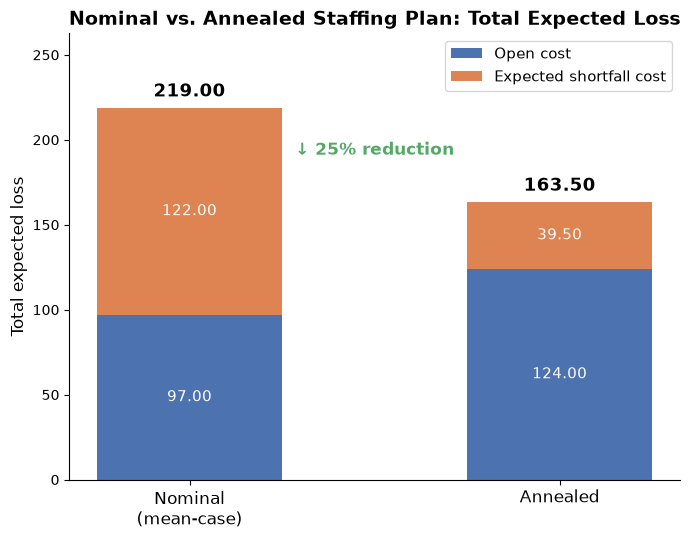

In [16]:
import matplotlib.pyplot as plt
import numpy as np

plans = ["Nominal\n(mean-case)", "Annealed"]
open_cost = [97.00, 124.00]
shortfall_cost = [122.00, 39.50]
totals = [219.00, 163.50]

x = np.arange(len(plans))
width = 0.5

fig, ax = plt.subplots(figsize=(7, 5.5))

ax.bar(x, open_cost, width, label="Open cost", color="#4C72B0")
ax.bar(x, shortfall_cost, width, bottom=open_cost, label="Expected shortfall cost", color="#DD8452")

for i, total in enumerate(totals):
    ax.text(x[i], total + 4, f"{total:.2f}", ha="center", va="bottom", fontsize=13, fontweight="bold")

for i in range(len(plans)):
    ax.text(x[i], open_cost[i] / 2, f"{open_cost[i]:.2f}", ha="center", va="center", color="white", fontsize=11)
    ax.text(x[i], open_cost[i] + shortfall_cost[i] / 2, f"{shortfall_cost[i]:.2f}", ha="center", va="center", color="white", fontsize=11)

ax.set_xticks(x)
ax.set_xticklabels(plans, fontsize=12)
ax.set_ylabel("Total expected loss", fontsize=12)
ax.set_title("Nominal vs. Annealed Staffing Plan: Total Expected Loss", fontsize=14, fontweight="bold")
ax.set_ylim(0, max(totals) * 1.2)
ax.legend(loc="upper right", fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

reduction_pct = (totals[0] - totals[1]) / totals[0] * 100
ax.annotate(
    f"↓ {reduction_pct:.0f}% reduction",
    xy=(0.5, (totals[0] + totals[1]) / 2),
    ha="center", fontsize=12, fontweight="bold", color="#55A868",
)

plt.tight_layout()
plt.show()

# Optional: save a copy into Colab's local filesystem (visible in the file browser on the left,
# and downloadable via files.download() below)
fig.savefig("nominal_vs_annealed_chart.png", dpi=200)